In [1]:
# Python functions to import

from collaborative_filtering.baseline_model import *
from collaborative_filtering.fastai_model import *
from collaborative_filtering.lightfm_model import *
from collaborative_filtering.sklearn_model import *
from collaborative_filtering.surprise_model import *

from content_filtering.baseline_model import *
from content_filtering.sklearn_model import *
from content_filtering.tfidf_model import *

In [2]:
# Python libraries to import

import matplotlib.pyplot as plt

In [3]:
# Read in the CSV file

review_data = pd.read_csv("dataset/processed_dataset/review.csv")

In [4]:
# Only keeping users that have made at least 25 reviews

user_counts = review_data['user_id'].value_counts()
filtered_user_ids = user_counts[user_counts > 25].index
review_data = review_data[review_data['user_id'].isin(filtered_user_ids)]

In [5]:
# Undersampling the data so that we can get a more accurate value of how the models are performing

rating_1 = review_data[review_data["stars"] == 1]
rating_2 = review_data[review_data["stars"] == 2]
rating_3 = review_data[review_data["stars"] == 3]
rating_4 = review_data[review_data["stars"] == 4]
rating_5 = review_data[review_data["stars"] == 5]

minimum_sample = min(review_data['stars'].value_counts())

rating_1 = rating_1.sample(minimum_sample, random_state=42)
rating_2 = rating_2.sample(minimum_sample, random_state=42)
rating_3 = rating_3.sample(minimum_sample, random_state=42)
rating_4 = rating_4.sample(minimum_sample, random_state=42)
rating_5 = rating_5.sample(minimum_sample, random_state=42)
 
balanced_df = pd.concat([rating_1,rating_2,rating_3,rating_4,rating_5])


In [6]:
%%capture

# Running each of the models with no hyperparameter optimisation, and making sure the code is not printing anything

baseline_score = collaborative_filtering_baseline(balanced_df)
fastai_score = fastai(balanced_df)
sklearn_score = sklearn(balanced_df)
surprise_score = surprise(balanced_df)
lightfm_score = lightfm(balanced_df)

In [7]:
# Setting up values for the graphing

value_dic = {'Baseline': baseline_score,'FastAI':fastai_score,'Sklearn':sklearn_score,'Surprise':surprise_score,'LightFM':lightfm_score}

In [8]:
# Sorting the data

sorted_data = sorted(value_dic.items(), key=lambda x: x[1])
models, scores = zip(*sorted_data)

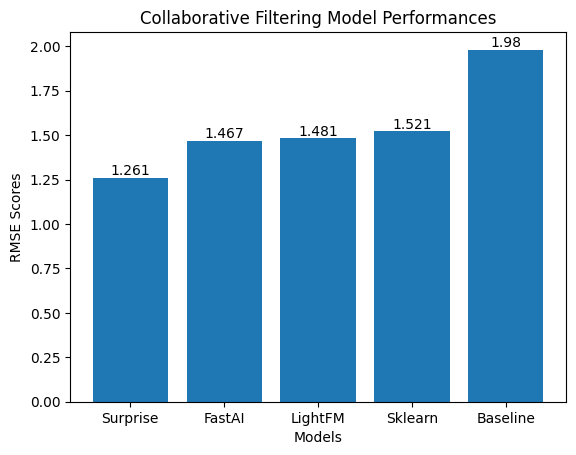

In [9]:
# Graph code

plt.bar(models, scores)

plt.xlabel('Models')
plt.ylabel('RMSE Scores')
plt.title('Collaborative Filtering Model Performances')

for model, score in zip(models, scores):
    rounded_score = round(score, 3)
    plt.text(model, score, str(rounded_score), ha='center', va='bottom')

plt.show()

In [10]:
%%capture

# Running each of the models with no hyperparameter optimisation, and making sure the code is not printing anything

fast_ai_hyperparameter_score = fastai_hyperparameter(balanced_df)
sklearn_hyperparameter_score = sklean_hyperparameter(balanced_df)
lightfm_hyperparameter_score = lightfm_hyperparameter(balanced_df)
surprise_hyperparameter_score = surprise_hyperparameter(balanced_df)

Estimating biases using als...
Estimating biases using als...
Estimating biases using als...
Estimating biases using als...
Estimating biases using als...
Estimating biases usingEstimating biases using als...
 als...
Estimating biases using als...
Estimating biases using als...
Estimating biases using als...
Estimating biases using als...
Estimating biases using als...
Estimating biases using als...
Estimating biases using als...
Estimating biases using als...
Estimating biases using als...
Estimating biases using als...
Estimating biases using als...
Estimating biases using als...
Estimating biases using als...
Estimating biases using als...
Estimating biases using als...
Estimating biases using als...
Estimating biases using als...
Estimating biases using als...
Estimating biases using als...
Estimating biases using als...
Estimating biases using als...
Estimating biases using als...
Estimating biases using als...
Estimating biases using als...
Estimating biases using als...
Estimati

In [39]:
model = ['FastAI','Sklearn','Surprise','LightFM']
scores = [fastai_score,sklearn_score,surprise_score,lightfm_score]
hyper_score = [float(fast_ai_hyperparameter_score),sklearn_hyperparameter_score,surprise_hyperparameter_score,float(lightfm_hyperparameter_score)]

In [40]:
print(model)
print(scores)
print(hyper_score)

['FastAI', 'Sklearn', 'Surprise', 'LightFM']
[1.466575, 1.5209842994572789, 1.2608691092107005, 1.4814973982822641]
[1.4043704271316528, 1.505460038412567, 1.2404538566482188, 1.4164154686459265]


In [41]:
data = list(zip(model, scores, hyper_score))
sorted_values = sorted(data, key=lambda x: x[2])
sorted_models, sorted_score, sorted_hyper_score = zip(*sorted_values)


ValueError: shape mismatch: objects cannot be broadcast to a single shape.  Mismatch is between arg 0 with shape (5,) and arg 1 with shape (4,).

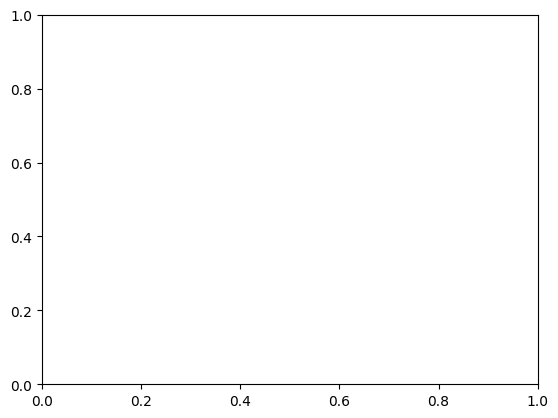

In [45]:
bar_width = 0.35
bar_positions1 = np.arange(len(models))
bar_positions2 = bar_positions1 + bar_width

# Create the grouped bar chart
plt.bar(bar_positions2, sorted_score, width=bar_width, label='Scores')
plt.bar(bar_positions1, sorted_hyper_score, width=bar_width, label='Hyperparameter Scores')

# Add labels and title
plt.xlabel('Models')
plt.ylabel('RMSE Scores')
plt.title('Model Performances')
plt.xticks(bar_positions1 + bar_width / 2, models)
plt.legend()

# Show the plot
plt.show()